# A. Cel ćwiczenia

Celem niniejszego projektu było zastosowanie oraz porównanie nienadzorowanych technik uczenia maszynowego (klasteryzacji) w analizie czasowych profili ekspresji genów. Ze względu na wysoką wymiarowość i objętość danych pochodzących z mikromacierzy DNA (ponad 600 genów mierzonych w 7 punktach czasowych), manualna interpretacja wyników jest niemożliwa. Zadaniem algorytmów było zatem automatyczne zidentyfikowanie ukrytych struktur w danych i pogrupowanie genów wykazujących zbliżoną dynamikę aktywności w czasie. W ramach ćwiczenia zestawiono ze sobą dwa fundamentalnie różne podejścia analityczne: algorytm K-średnich (K-Means) oraz grupowanie hierarchiczne (aglomeracyjne). Istotnym celem projektu była ocena i porównanie skuteczności obu metod, w tym zbadanie mechaniki działania, wrażliwości na optymalizację parametrów (takich jak wielokrotna inicjalizacja). Ostatecznym celem analizy było wyodrębnienie spójnych grup genów oraz wykorzystanie modelu do klasyfikacji nowych, nieznanych profili genetycznych.

# B. Opis używanych metod i algorytmów

W poniższym rozdziale omówiono kluczowe koncepcje matematyczne i algorytmiczne, które posłużyły do analizy profili ekspresji genów. Zastosowane metody opierają się na nienadzorowanym uczeniu maszynowym (unsupervised learning), którego celem jest odkrywanie ukrytych struktur w danych bez wcześniejszej znajomości etykiet (przynależności do grup).

##**1. Podstawa analizy: Odległość Euklidesowa**

Aby jakikolwiek algorytm mógł pogrupować geny, musi najpierw umieć zmierzyć ich wzajemne podobieństwo. W tym projekcie miarą "niepodobieństwa" profili ekspresji w czasie była standardowa odległość Euklidesowa. Dla dwóch profili genów (punktów w n-wymiarowej przestrzeni) oznaczonych jako wektory $p$ i $q$, odległość tę definiuje wzór:<br><br>
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$<br>Gdzie $n$ to liczba punktów pomiarowych (np. momentów w czasie). Im mniejsza odległość, tym bardziej zbliżona jest dynamika aktywności obu genów.

##**2. Analiza Głównych Składowych (PCA)**

Analiza Głównych Składowych (Principal Component Analysis) to fundamentalna technika redukcji wymiarowości. W analizowanym problemie profile genów mierzono w 7 punktach czasowych, co tworzyło 7-wymiarową przestrzeń. PCA pozwala na rzutowanie tych danych na przestrzeń o mniejszej liczbie wymiarów (np. 2D lub 3D), zachowując przy tym maksymalną możliwą ilość informacji (wariancji). Działanie algorytmu PCA można opisać w czterech kluczowych krokach matematycznych:<br><br>

**Krok 1: Standaryzacja danych**

Przed przystąpieniem do analizy, dane muszą zostać wycentrowane i przeskalowane, aby zmienne o większych zakresach wartości nie zdominowały wyników. Od każdej wartości odejmowana jest średnia ($\mu$), a wynik dzielony jest przez odchylenie standardowe ($\sigma$):<br><br>$$z = \frac{x - \mu}{\sigma}$$<br>

**Krok 2: Wyznaczenie macierzy kowariancji**

Algorytm bada, jak zmienne (np. punkty czasowe) są ze sobą powiązane. W tym celu obliczana jest macierz kowariancji. Kowariancja między dwiema zmiennymi $X$ i $Y$ (dla próbki o rozmiarze $n$) wyraża się wzorem:<br><br>$$cov(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$$<br>Ponieważ w Kroku 1 dane zostały wystandaryzowane, macierz kowariancji jest w tym przypadku matematycznie tożsama z macierzą korelacji Pearsona. Dodatnia wartość oznacza, że geny zachowują się podobnie w obu punktach czasowych.<br><br>

**Krok 3: Wyznaczenie wektorów własnych i wartości własnych**

Na podstawie macierzy kowariancji (oznaczmy ją jako $\Sigma$) rozwiązywane jest równanie charakterystyczne:<br><br>$$\Sigma v = \lambda v$$<br>Gdzie $v$ to wektor własny, a $\lambda$ to odpowiadająca mu wartość własna. Wektory własne wyznaczają nowe, ortogonalne (prostopadłe do siebie) osie w przestrzeni – to są właśnie nasze Główne Składowe (PC1, PC2, itd.). Wartości własne informują, jak dużo całkowitej wariancji (informacji) danych tłumaczy dana składowa.<br><br>

**Krok 4: Transformacja danych**

Wektory własne są sortowane malejąco według ich wartości własnych. Następnie wybiera się $k$ pierwszych wektorów (najczęściej dwa lub trzy, tworząc macierz wag $W$), które tłumaczą największy procent wariancji. Ostatecznie, oryginalny zbiór danych $X$ jest rzutowany na nowe osie poprzez mnożenie macierzy:<br><br>$$Y = X \cdot W$$<br>Gdzie $Y$ to nowa, zredukowana macierz danych, którą możemy przedstawić na dwuwymiarowym wykresie (scatter plot), wizualnie oceniając skupiska genów.

##**3. Grupowanie: Algorytm K-średnich (K-Means)**

Algorytm K-średnich dzieli zbiór danych na z góry zadaną liczbę $K$ rozłącznych klastrów. Jego działanie opiera się na iteracyjnej optymalizacji, która minimalizuje wariancję wewnątrzgrupową, znaną również jako Inercja.

Matematycznie, inercja to suma kwadratów odległości euklidesowych każdego punktu $x_i$ od środka ciężkości jego grupy (centroidu $c_j$):<br><br>$$J = \sum_{j=1}^{K} \sum_{x_i \in C_j} ||x_i - c_j||^2$$<br>
**Mechanika algorytmu:**<br><br>

1. Odgórna inicjalizacja $K$ centroidów.<br><br>
2. Przypisanie każdego punktu do najbliższego centroidu (odległość euklidesowa).<br><br>
3. Aktualizacja pozycji centroidów (wyliczenie nowej średniej arytmetycznej z punktów w grupie).<br><br>
4. Kroki 2 i 3 są powtarzane aż do momentu, w którym centroidy przestaną się przesuwać.<br><br>

Ponieważ K-Means jest wrażliwy na początkowe losowanie centroidów (ryzyko utknięcia w minimum lokalnym), stosuje się wielokrotną inicjalizację algorytmu (parametr n_init), wybierając model z najniższą końcową inercją.

##**4. Grupowanie hierarchiczne (Aglomeracyjne)**

W przeciwieństwie do algorytmu K-średnich, grupowanie aglomeracyjne buduje hierarchię podobieństw (dendrogram) metodą "z dołu do góry" (bottom-up). Na starcie algorytmu każdy gen stanowi osobną, jednoelementową grupę. W każdym kolejnym kroku dwie najbardziej podobne do siebie grupy są łączone w jedną, aż cały zbiór utworzy jeden główny klaster.

Decyzję o tym, które grupy połączyć w danym kroku, determinuje tzw. kryterium łączenia (linkage). W niniejszej analizie zastosowano Metodę Warda (Ward's linkage). W odróżnieniu od najprostszych metod (badających np. odległość między najbliższymi lub najdalszymi punktami dwóch klastrów), metoda Warda opiera się na analizie wariancji. Jej celem jest łączenie tych klastrów, które spowodują najmniejszy przyrost całkowitej wariancji wewnątrzgrupowej. W ujęciu obliczeniowym (geometrycznym), odległość Warda między dwoma klastrami $A$ i $B$ wyznaczana jest na bazie odległości Euklidesowej pomiędzy ich środkami ciężkości (centroidami), "zważonej" przez ich liczebność. Równanie przyjmuje postać:<br><br>$$d_{Ward}(A, B) = \sqrt{\frac{2 n_A n_B}{n_A + n_B}} \cdot d_{Eukl}(\mu_A, \mu_B)$$<br>Gdzie: $n_A, n_B$ – liczba obserwacji (genów) w łączonych klastrach $A$ i $B$,$\mu_A, \mu_B$ – wektory średnich wartości (centroidy) dla klastrów $A$ i $B$,$d_{Eukl}$ – klasyczna odległość Euklidesowa między wyznaczonymi centroidami.

Co niezwykle istotne w analizie profili biologicznych, ze względu na specyfikę tego dystansu, metoda Warda jest wysoce niewrażliwa na odstające dane (outliery). Nietypowe, zaszumione profile genów są izolowane w osobnych, niewielkich gałęziach drzewa, nie zaburzając spójności głównych trendów eksperymentu.

##**5. Ocena jakości klastrowania: Metryka Silhouette**

Aby obiektywnie porównać wyniki różnych algorytmów oraz zweryfikować poprawność dobrania liczby grup, zastosowano wskaźnik sylwetkowy (Silhouette Score). Dla każdego punktu $i$ (genu) miara ta bada relację między dwoma wartościami: $a(i)$ – średnia odległość punktu $i$ od wszystkich innych punktów w tej samej grupie (miara spójności grupy). $b(i)$ – średnia odległość punktu $i$ od wszystkich punktów z najbliższej sąsiedniej grupy (miara separacji grup). Wzór na wskaźnik sylwetkowy dla pojedynczego punktu przyjmuje postać:<br><br>$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$<br>Wynik uśredniony dla całego zbioru przyjmuje wartości z przedziału $[-1, 1]$. Wynik bliski $1$ oznacza doskonałą spójność i separację klastrów, wynik około $0$ sugeruje, że grupy nakładają się na siebie (rozmyte granice), natomiast wartości ujemne wskazują na błędne przypisanie punktów.

#C. Raport

###**Krok 1: Inicjalizacja danych i redukcja wymiarowości (PCA)**

*Opis kroku: Wczytanie poziomów ekspresji dla 614 genów oraz wizualizacja rozkładu danych przy wykorzystaniu analizy głównych składowych (PCA).*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import (KMeans , AgglomerativeClustering)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import (dendrogram , cut_tree)
from ISLP.cluster import compute_linkage
from statsmodels.datasets import get_rdataset
from ISLP import load_data

In [ ]:
data= pd.read_csv("GD_dane_genetyczne.csv")
geny = data.iloc[:,0].tolist()
ekspresja = data.iloc[:,1:].to_numpy()
czas = data.columns[1:].to_numpy()
czas = list(map(float, czas))
nr_gr = 5.1
r_k = 2026
np.random.seed(int(nr_gr*r_k))
ekspresja = ekspresja + np.random.rand(614, 7) * 0.1 - 0.05

In [ ]:
print(data)

           -      0    9.5   11.5   13.5   15.5   18.5   20.5
0     SS DNA -0.131  1.699 -0.026  0.365 -0.246  0.478  0.435
1    YAL003W  0.305  0.146 -0.129 -0.444 -0.707 -1.499 -1.935
2    YAL012W  0.157  0.175  0.467 -0.379 -0.520 -1.279 -2.125
3    YAL026C  0.246  0.796  0.384  0.981  1.020  1.646  1.157
4    YAL034C -0.235  0.487 -0.184 -0.669 -1.006  2.369  2.611
..       ...    ...    ...    ...    ...    ...    ...    ...
609  YPR136C  0.158 -0.130 -0.880 -0.693 -1.020 -2.387 -1.009
610  YPR150W -0.306 -0.446 -0.359  0.021  0.148  1.619  1.674
611  YPR156C  0.074  0.535  1.603  1.461  1.580  0.933  2.044
612  YPR184W -0.195  0.165 -0.333  0.421  0.858  1.633  3.028
613  NORF 46 -0.247  0.110  0.042  0.684  1.070  0.845  2.328

[614 rows x 8 columns]


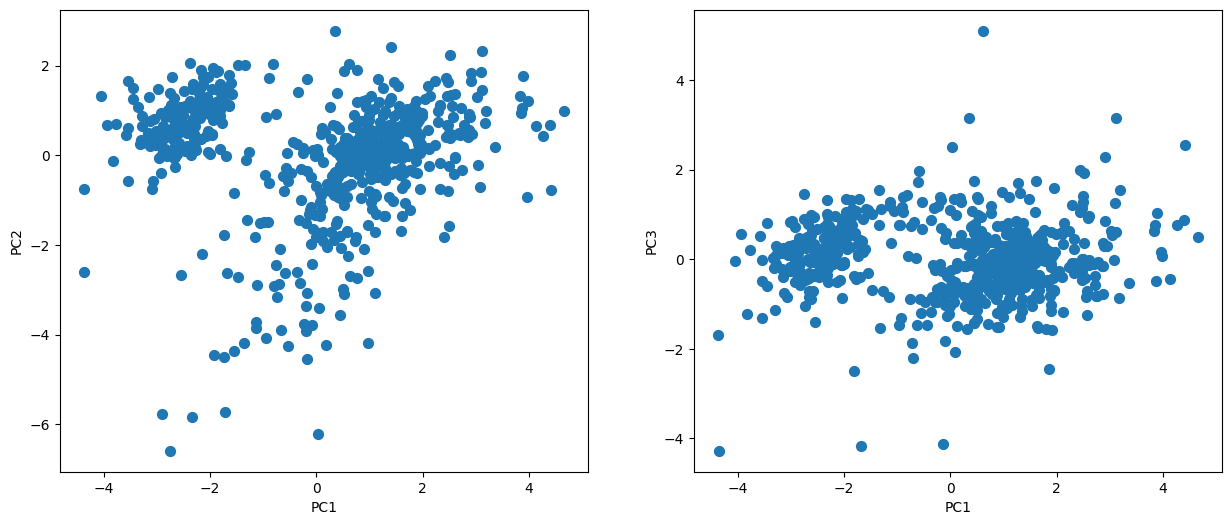

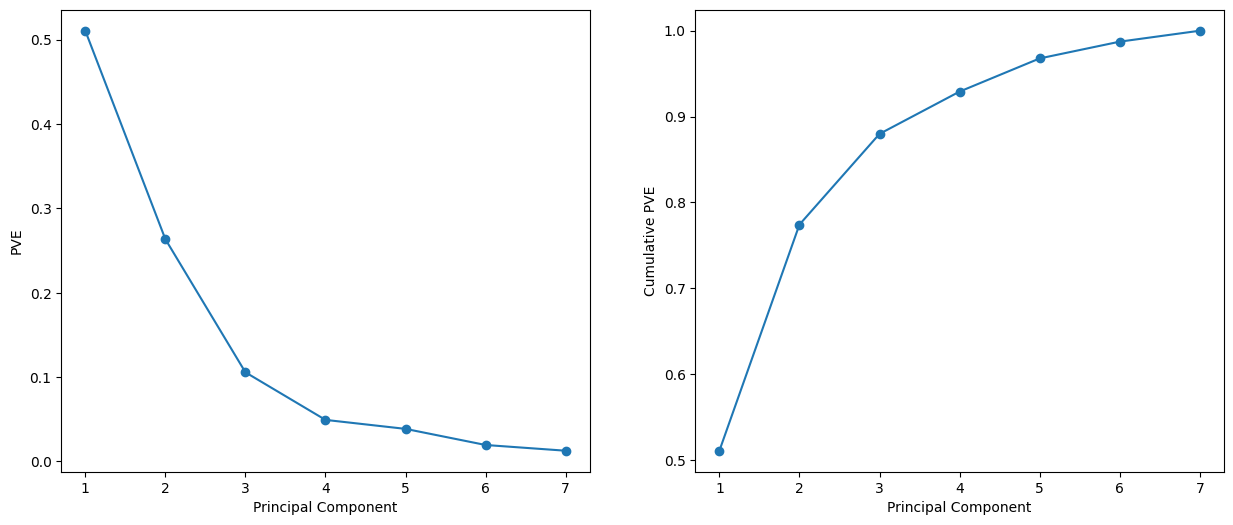

In [ ]:
scaler = StandardScaler()
ekspresja_scaled = scaler.fit_transform(ekspresja)

pca = PCA()
ekspresja_scores = pca.fit_transform(ekspresja_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(
    ekspresja_scores[:, 0],   # PC1
    ekspresja_scores[:, 1],   # PC2
    marker='o',
    s=50
)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

ax = axes[1]
ax.scatter(
    ekspresja_scores[:, 0],   # PC1
    ekspresja_scores[:, 2],   # PC3
    marker='o',
    s=50
)
ax.set_xlabel('PC1')
ax.set_ylabel('PC3')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ticks = np.arange(pca.n_components_) + 1
ax.plot(
    ticks,
    pca.explained_variance_ratio_,
    marker='o'
)

ax.set_xlabel('Principal Component')
ax.set_ylabel('PVE')

ax = axes[1]
ax.plot(
    ticks,
    pca.explained_variance_ratio_.cumsum(),
    marker='o'
)

ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative PVE')
plt.show()

**Kluczowe wnioski z analizy PCA:**

1. Wysoka skuteczność redukcji **(Wykresy PVE):** Pierwsze dwie główne składowe (PC1 i PC2) tłumaczą łącznie blisko **80% całkowitej wariancji (informacji)** w danych. Dodanie PC3 podnosi ten wynik do prawie 90%. Oznacza to, że redukcja 7-wymiarowych danych do prostej przestrzeni 2D jest bardzo udana i wiąże się z minimalną utratą ważnych informacji.

2. Widoczna struktura danych **(Wykresy rozrzutu):** Rzuty punktów (zwłaszcza PC1 vs PC2) wyraźnie udowadniają nielosowość danych. Widać na nich naturalne tendencje do formowania się gęstych skupisk (chmur punktów). To ostateczny dowód na to, że w profilach genów istnieją silne, ukryte wzorce, a zbiór idealnie nadaje się do zastosowania algorytmów klasteryzacji.

###**Krok 2: Segmentacja profili algorytmem K-Means**
*Opis kroku: Pogrupowanie profili na 16 klastrów i wizualizacja wyników w przestrzeni zredukowanej (PCA) wraz z identyfikacją centroidów dla poszczególnych grup.*

In [ ]:
kmeans = KMeans(n_clusters=16, random_state=2, n_init=20)
kmeans_labels = kmeans.fit_predict(ekspresja)

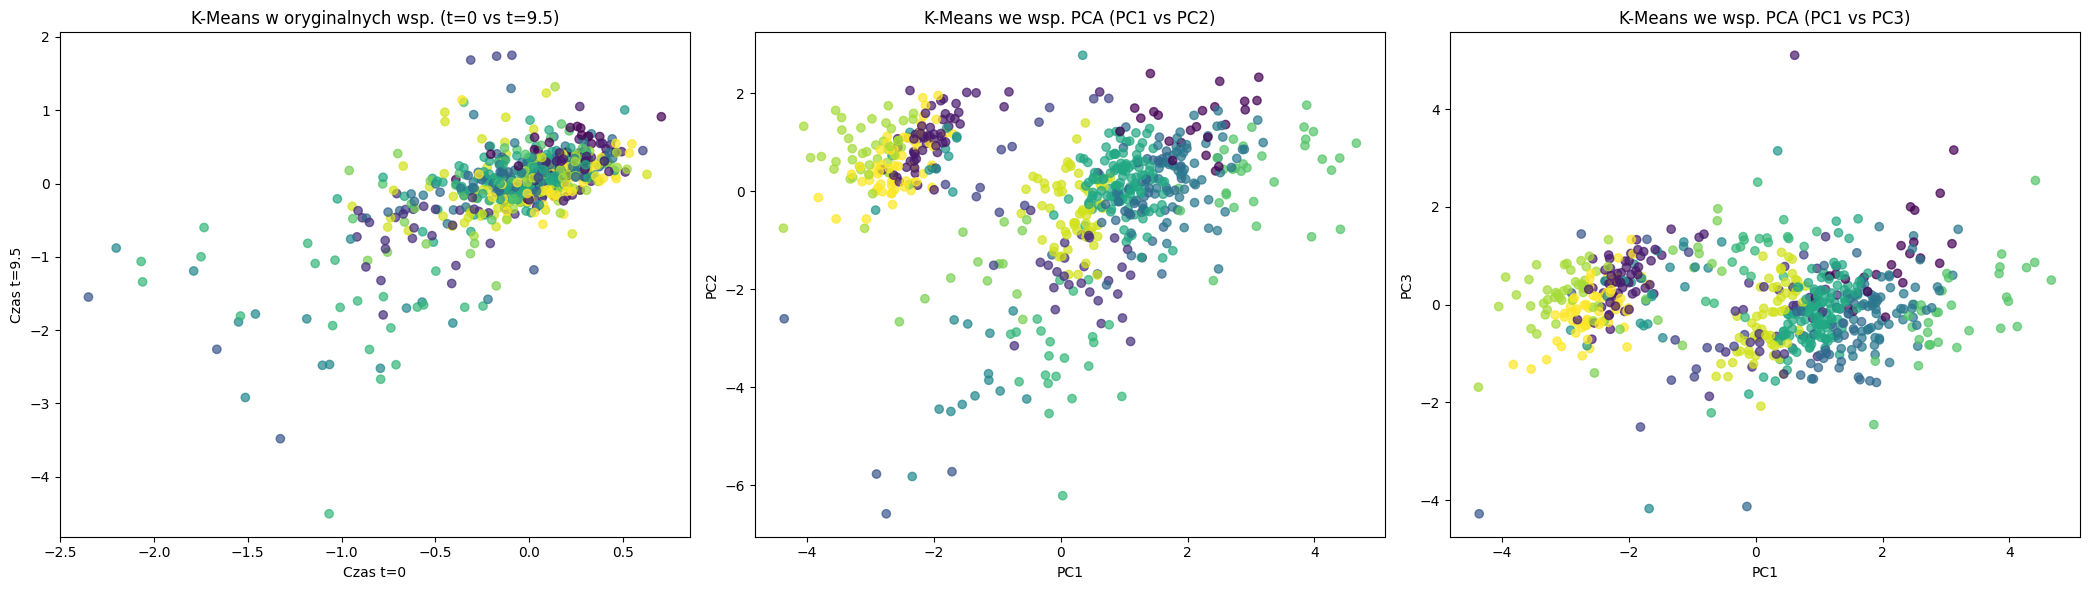

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))

# Współrzędne oryginalne
ax1.scatter(ekspresja[:, 0], ekspresja[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
ax1.set_title('K-Means w oryginalnych wsp. (t=0 vs t=9.5)')
ax1.set_xlabel('Czas t=0')
ax1.set_ylabel('Czas t=9.5')

scaler = StandardScaler()
ekspresja_scaled = scaler.fit_transform(ekspresja)
pca = PCA()
ekspresja_scores = pca.fit_transform(ekspresja_scaled)

# Współrzędne PCA (PC1 vs PC2)
ax2.scatter(ekspresja_scores[:, 0], ekspresja_scores[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
ax2.set_title('K-Means we wsp. PCA (PC1 vs PC2)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

# Współrzędne PCA (PC1 vs PC3)
ax3.scatter(ekspresja_scores[:, 0], ekspresja_scores[:, 2], c=kmeans_labels, cmap='viridis', alpha=0.7)
ax3.set_title('K-Means we wsp. PCA (PC1 vs PC3)')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC3')

plt.tight_layout()
plt.show()

**Kluczowe wnioski z wizualizacji klastrów (K-Means + PCA):**

**1. Ograniczenia surowych danych (Wykres 1):** Rzut na oryginalne współrzędne (czas t=0 vs t=9.5) to wizualny chaos – klastry (kolory) mocno się na siebie nakładają. Udowadnia to, że wybiórcza analiza tylko dwóch pojedynczych punktów czasowych nie pozwala dostrzec prawdziwych różnic między genami, które istnieją w pełnej, 7-wymiarowej przestrzeni.

**2. Połączenie PCA i K-Means (Wykresy 2 i 3):** Rzutowanie na Główne Składowe drastycznie poprawia separację. Kolory przypisane przez algorytm K-Means w 7-wymiarowej przestrzeni układają się w bardzo wyraźne, oddzielone od siebie "wyspy" na wykresach PC1 vs PC2 oraz PC1 vs PC3. To wizualny dowód na to, że algorytm zadziałał poprawnie.

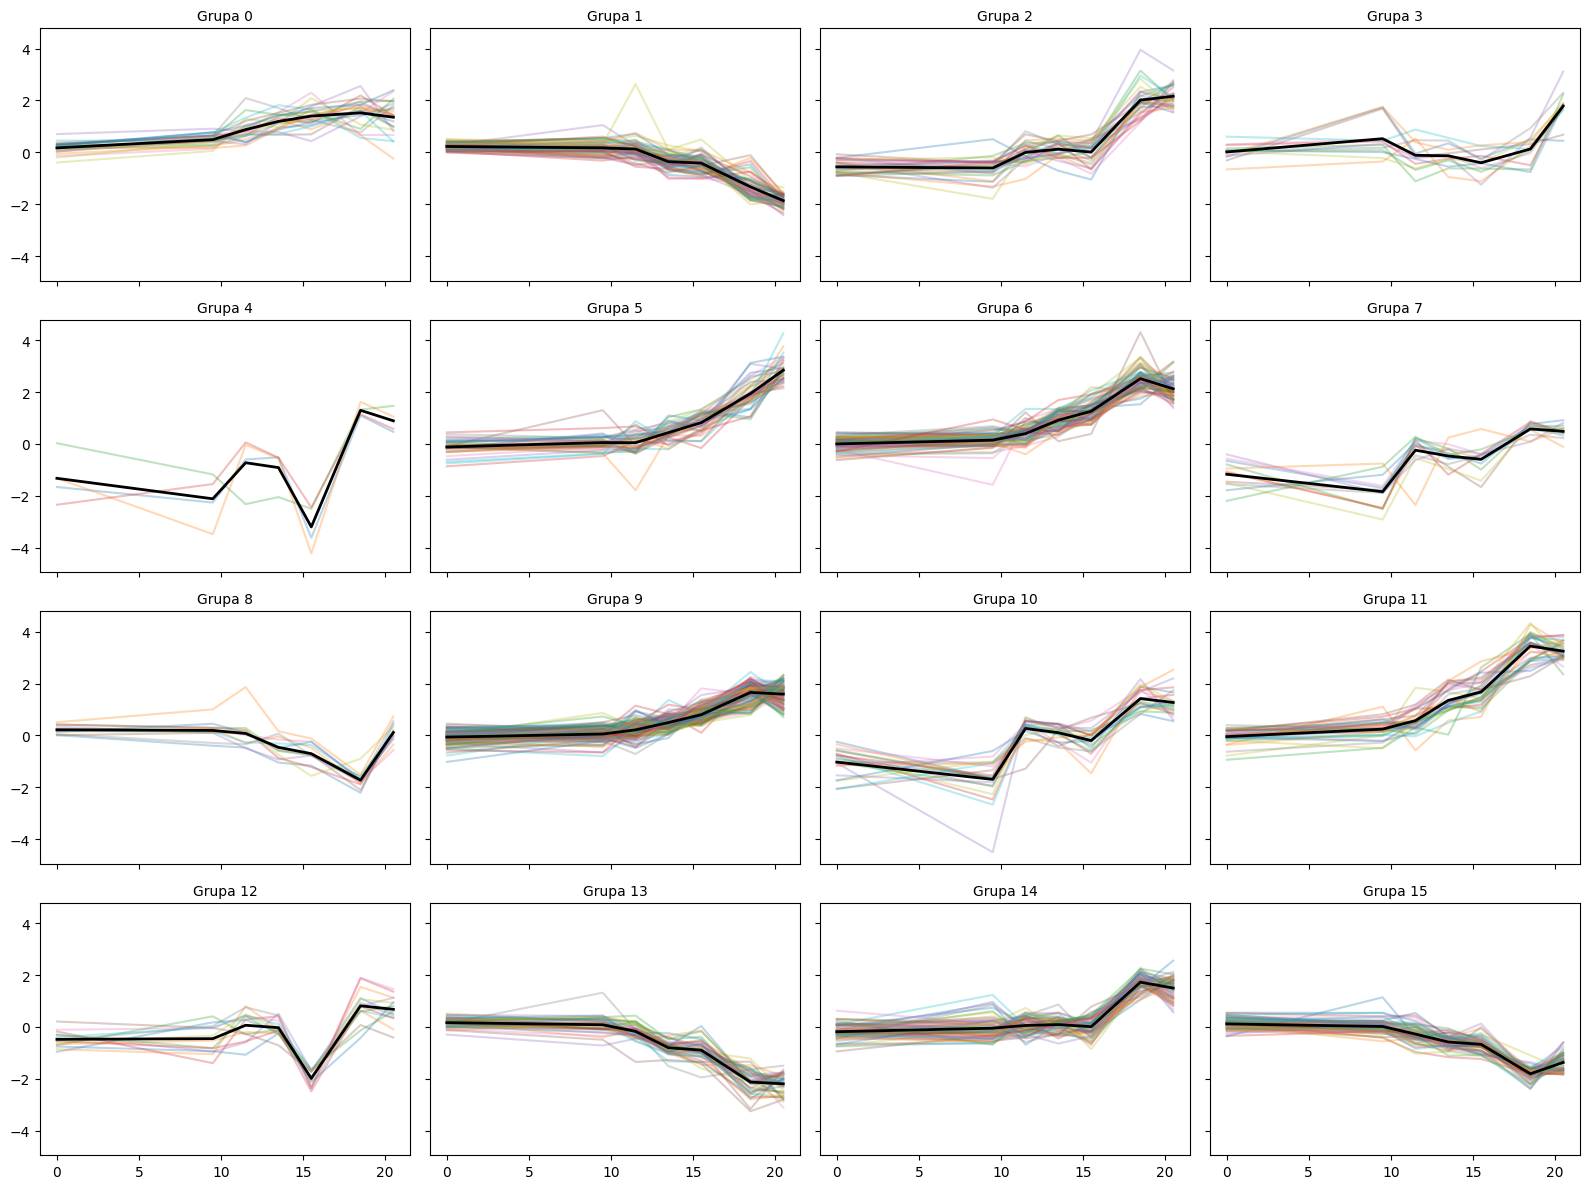

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(16):
    cluster_data = ekspresja[kmeans_labels == i]

    for profile in cluster_data:
        axes[i].plot(czas, profile, alpha=0.3)

    # Rysowanie centroidu
    axes[i].plot(czas, kmeans.cluster_centers_[i], color='black', linewidth=2)
    axes[i].set_title(f'Grupa {i}', fontsize=10)

plt.tight_layout()
plt.show()

**Kluczowe wnioski z profili ekspresji w klastrach (K-Means):**

**1. Identyfikacja unikalnych trendów:** Algorytm z powodzeniem wyodrębnił różnorodne, biologicznie sensowne wzorce dynamiki ekspresji. Widzimy tu wyraźne "rodziny" genów: np. silnie aktywowane w późnej fazie (grupy 2, 6, 11), systematycznie wygaszane (grupy 1, 13, 15) oraz takie o nagłych, przejściowych skokach aktywności (grupy 4, 12).

**2. Rola centroidów (czarne linie):** Pogrubiona czarna linia w każdym oknie to wyliczony matematycznie środek ciężkości grupy (centroid). Wykres udowadnia, że centroidy doskonale pełnią rolę "sygnatur" – idealnie uśredniają i reprezentują globalny trend dla przypisanych do nich genów.

**3. Wizualna ocena wariancji:** Wykres pozwala naocznie ocenić spójność klastrów. Większość grup (np. 1, 6, 9, 15) jest bardzo zwarta (kolorowe linie ciasno oplatają czarną), co świadczy o wysokiej jakości klastrowania. Algorytm wydzielił też grupy nieco luźniejsze (np. 4, 7, 10), do których zrzucił geny o rzadszych, bardziej zaszumionych profilach.

###**Krok 3: Optymalizacja liczby klastrów i badanie stabilności algorytmu**
*Opis kroku: Analiza zależności wariancji wewnątrzgrupowej (inertia) od liczby grup (Metoda Łokcia / Elbow Method) oraz weryfikacja wpływu stanów początkowych algorytmu na zbieżność.*

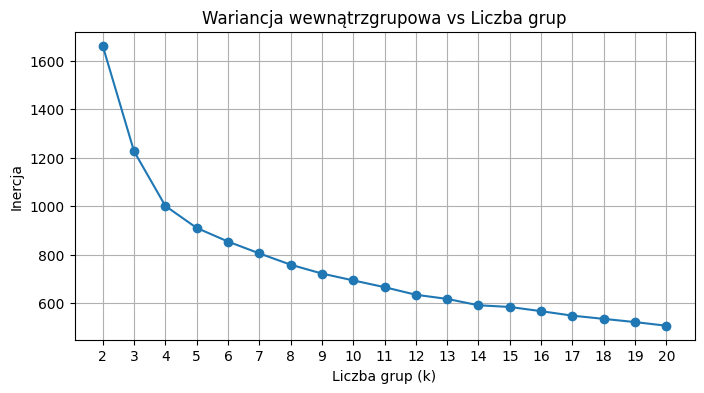

In [ ]:
inertias_k = []
k_values = range(2, 21)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=2).fit(ekspresja)
    inertias_k.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias_k, marker='o')
plt.title('Wariancja wewnątrzgrupowa vs Liczba grup')
plt.xlabel('Liczba grup (k)')
plt.ylabel('Inercja')
plt.xticks(k_values)
plt.grid(True)
plt.show()

**Kluczowe wnioski z wykresu Inercji:**

1. **Brak jednoznacznego "łokcia":** Wykres obrazuje spadek wariancji wewnątrzgrupowej (inercji) wraz ze wzrostem liczby klastrów. Największy zysk (ostry spadek) obserwujemy na samym początku, a punkt przegięcia (tzw. "łokieć") zarysowuje się dość łagodnie w okolicach $k=4$ lub $k=5$.

2. **Marginalne zyski dla wyższych $k$:** W prawej części wykresu krzywa ulega silnemu wypłaszczeniu. Oznacza to, że każde kolejne zwiększenie liczby klastrów (np. z 15 na 16) redukuje błąd wariancji już tylko minimalnie.

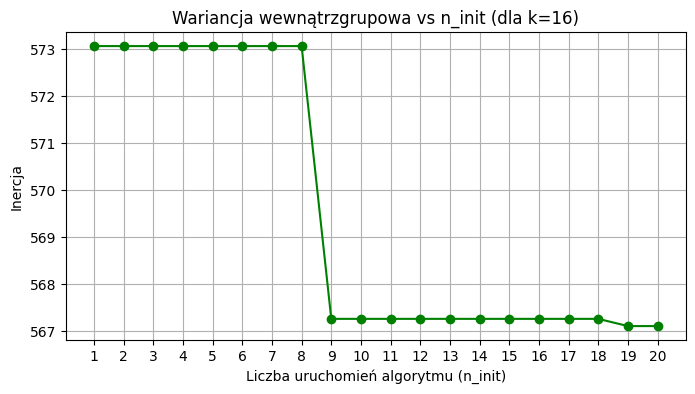

In [ ]:
inertias_init = []
init_values = range(1, 21)

for n in init_values:
    km = KMeans(n_clusters=16, n_init=n, random_state=2).fit(ekspresja)
    inertias_init.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(init_values, inertias_init, marker='o', color='green')
plt.title('Wariancja wewnątrzgrupowa vs n_init (dla k=16)')
plt.xlabel('Liczba uruchomień algorytmu (n_init)')
plt.ylabel('Inercja')
plt.xticks(init_values)
plt.grid(True)
plt.show()

**Kluczowe wnioski z analizy parametru n_init (wielokrotnej inicjalizacji):**

1. **Wykres udowadnia**, dlaczego nie wolno ufać pojedynczemu uruchomieniu algorytmu K-Means. Przez pierwsze 8 prób model utykał w gorszym, nieoptymalnym podziale o wyższej wariancji (inercja ok. 573). Gdybyśmy ustawili n_init=1, otrzymalibyśmy błędny model.

2. **Przełamanie i optymalizacja:** Dopiero przy 9. losowaniu początkowych centroidów algorytm odnalazł znacznie lepszą konfigurację przestrzenną klastrów, co widać jako gwałtowny spadek błędu na wykresie. Kolejna, bardzo marginalna poprawa nastąpiła jeszcze przy 19. iteracji.

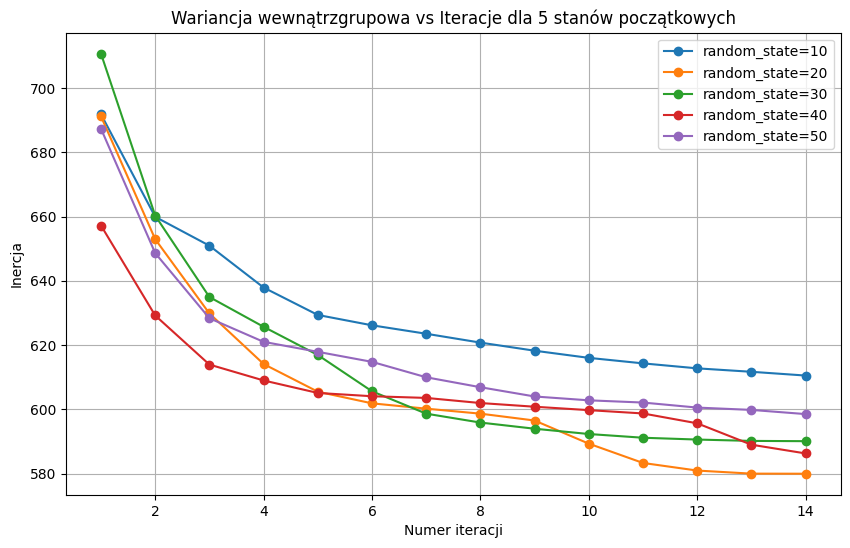

In [ ]:
plt.figure(figsize=(10, 6))
states = [10, 20, 30, 40, 50]

for rs in states:
    inertias_iter = []
    # Ręczne wymuszanie zakończenia po i iteracjach
    for i in range(1, 15):
        km = KMeans(n_clusters=16, n_init=1, random_state=rs, max_iter=i, init='random')
        km.fit(ekspresja)
        inertias_iter.append(km.inertia_)
    plt.plot(range(1, 15), inertias_iter, marker='o', label=f'random_state={rs}')

plt.title('Wariancja wewnątrzgrupowa vs Iteracje dla 5 stanów początkowych')
plt.xlabel('Numer iteracji')
plt.ylabel('Inercja')
plt.legend()
plt.grid(True)
plt.show()

**Kluczowe wnioski z analizy wpływu stanów początkowych (random_state):**

1. **Znaczenie punktu startowego:** Wykres idealnie ilustruje losową naturę K-Means. Różne ziarna losowości powodują drastycznie różne wartości błędu na starcie (np. linia zielona zaczyna z najwyższym błędem, a czerwona z najniższym).

2. **Dynamika zbieżności algorytmu:** Niezależnie od punktu startowego, model uczy się najszybciej w pierwszych 3-4 iteracjach (najbardziej stromy spadek krzywych), kiedy to centroidy pokonują największe odległości. Powyżej 8-10 iteracji wykresy ulegają silnemu wypłaszczeniu.

###**Krok 4: Grupowanie aglomeracyjne (Hierarchiczne)**
*Opis kroku: Alternatywne podejście do segmentacji danych genetycznych zwizualizowane za pomocą struktury dendrogramu z odpowiednio dobranym progiem odcięcia dla 16 grup.*

Przykładowe przypisania do grup dla pierwszych 10 genów: [0 1 1 2 3 3 2 4 2 5]


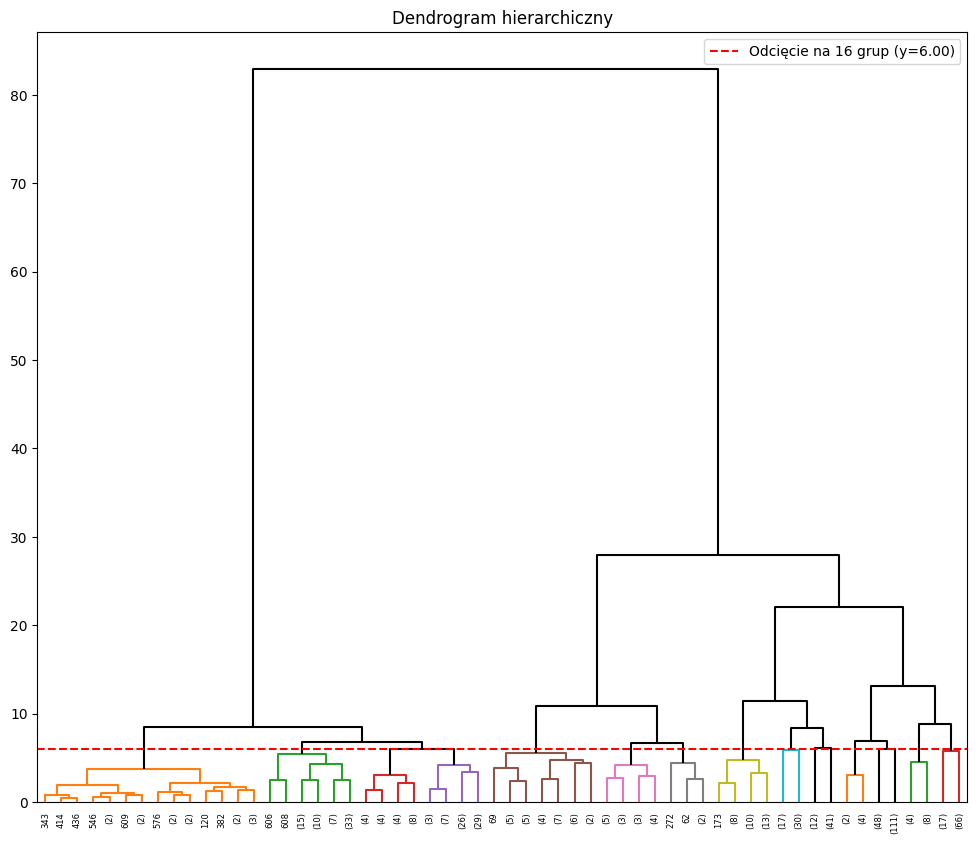

In [ ]:
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0, n_clusters=None, linkage='ward')
hc_comp.fit(ekspresja)
linkage_comp = compute_linkage(hc_comp)

agg_labels = cut_tree(linkage_comp, n_clusters=16)[:, 0]
print("Przykładowe przypisania do grup dla pierwszych 10 genów:", agg_labels[:10])

threshold = linkage_comp[-15, 2]
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

dendrogram(linkage_comp,
           ax=ax,
           color_threshold=threshold,
           above_threshold_color='black',
           truncate_mode='level',
           p=5)

ax.axhline(y=threshold, color='r', linestyle='--', label=f'Odcięcie na 16 grup (y={threshold:.2f})')
ax.set_title('Dendrogram hierarchiczny')
ax.legend()
plt.show()

**Kluczowe wnioski z grupowania hierarchicznego (Dendrogram):**

1. **Fundamentalny podział biologiczny:** Na samej górze drzewa (dystans powyżej 80) widać jeden gigantyczny, pierwotny podział całego zbioru na dwie główne gałęzie. Oznacza to, że pomijając drobne niuanse, wszystkie badane geny dzielą się na dwa skrajnie odmienne wzorce zachowań w czasie.

2. **Mechanika wyboru liczby klastrów:** Czerwona, przerywana linia na poziomie $y=6.00$ doskonale wizualizuje, jak z ciągłej hierarchii uzyskujemy dyskretne grupy. Przecięcie drzewa na tej konkretnej wysokości odcina dokładnie 16 pionowych gałęzi, co pozwala na bezpośrednie porównanie tego modelu z wcześniejszym algorytmem K-Means.

3. **Wizualizacja zróżnicowanej spójności:** Oś Y reprezentuje miarę odległości między łączonymi grupami. Gałęzie łączące się bardzo nisko (np. pomarańczowe po lewej stronie) oznaczają podgrupy genów o profilach niemal identycznych. Im wyżej następuje połączenie, tym bardziej różnorodne są profile wpadające do jednego worka.

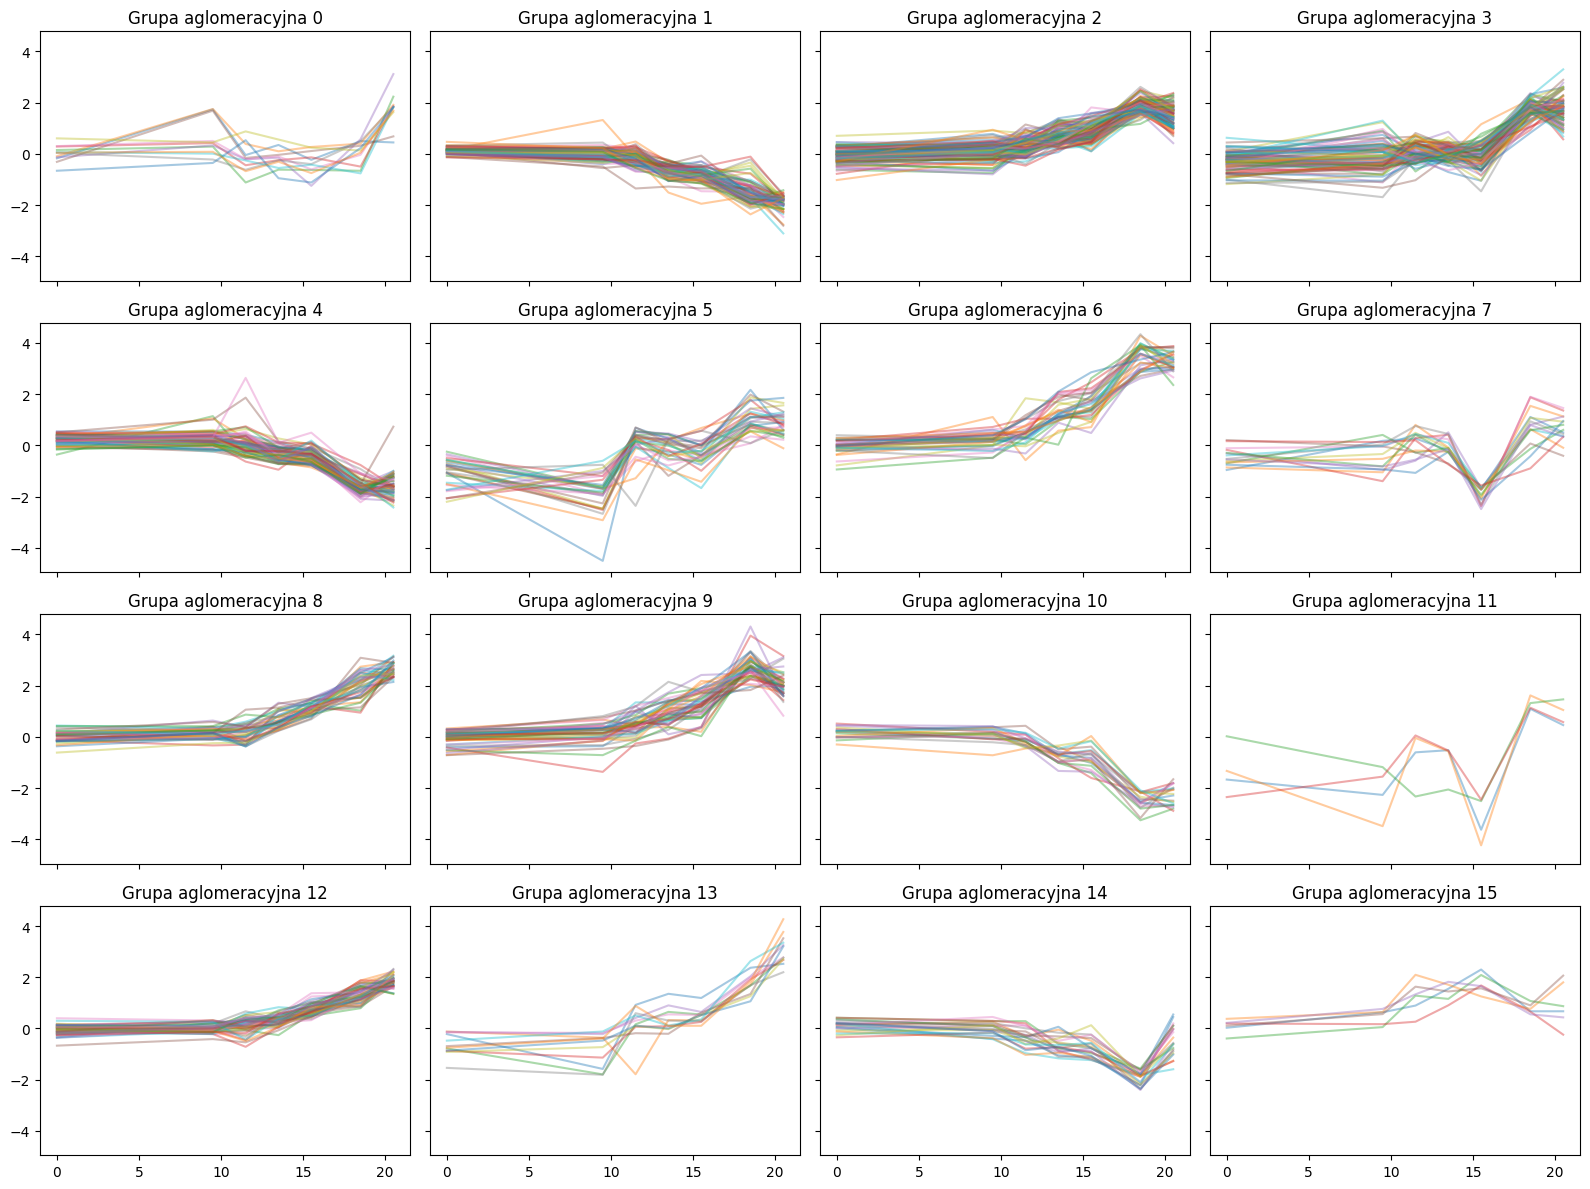

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(16):
    cluster_data = ekspresja[agg_labels == i]

    for profile in cluster_data:
        axes[i].plot(czas, profile, alpha=0.4)

    axes[i].set_title(f'Grupa aglomeracyjna {i}')

plt.tight_layout()
plt.show()

**Kluczowe wnioski z profili ekspresji w klastrach (Grupowanie aglomeracyjne):**

1. **Wysoka spójność wewnątrz klastrów:** Podobnie jak K-Means, algorytm hierarchiczny skutecznie rozpoznał i pogrupował rodziny genów o wspólnej dynamice. Grupy takie jak 2, 6, 8 czy 12 są niezwykle zwarte, co udowadnia, że wybrane kryterium odcięcia dendrogramu (16 grup) zadziałało poprawnie i stworzyło mocne biologicznie podziały.

3. **Skuteczna izolacja szumu:** Algorytm jest odporny na wartości odstające (outliery) – zamiast na siłę wciskać nietypowe, zaszumione profile do dużych, ładnych klastrów, zepchnął je do osobnych, małych grup izolując od reszty eksperymentu.

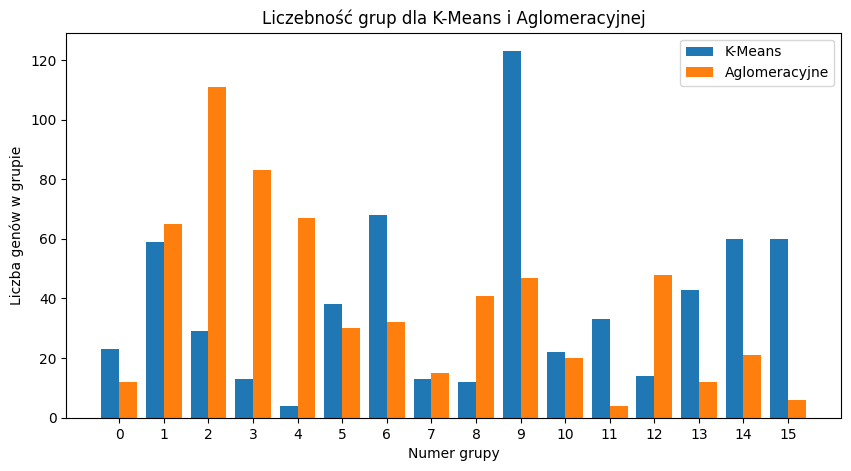

In [ ]:
kmeans_counts = np.bincount(kmeans_labels)

agg_counts = np.bincount(agg_labels)
x_bars = np.arange(16)

plt.figure(figsize=(10, 5))
plt.bar(x_bars - 0.2, kmeans_counts, width=0.4, label='K-Means')
plt.bar(x_bars + 0.2, agg_counts, width=0.4, label='Aglomeracyjne')
plt.xticks(x_bars)
plt.title('Liczebność grup dla K-Means i Aglomeracyjnej')
plt.xlabel('Numer grupy')
plt.ylabel('Liczba genów w grupie')
plt.legend()
plt.show()

**Kluczowe wnioski z analizy liczebności klastrów (Porównanie metod):**

1. **Naturalna asymetria:** Obie metody wygenerowały grupy o drastycznie różnej liczebności. Wynik udowadnia, że algorytmy szukają rzeczywistych, twardych wzorców w danych.

2. **Różnice w podziale:** Widać odmienną strategię działania obu algorytmów. K-Means skleił ogromną część genów w jeden dominujący klaster (grupa 9). Z kolei metoda hierarchiczna z kryterium Warda rozbiła dominujące trendy na kilka mniejszych, ale wciąż dużych klastrów (grupy 2, 3, 4), jednocześnie tworząc bardzo małe, kilkuelementowe wyspy (grupy 11, 15), co potwierdza jej skłonność do silnej izolacji wartości odstających.

###**Krok 5: Ocena jakości klasteryzacji**
*Opis kroku: Porównanie wyników obu metod segmentacji za pomocą metryki Silhouette (Silhouette Score) w celu weryfikacji spójności utworzonych klastrów.*

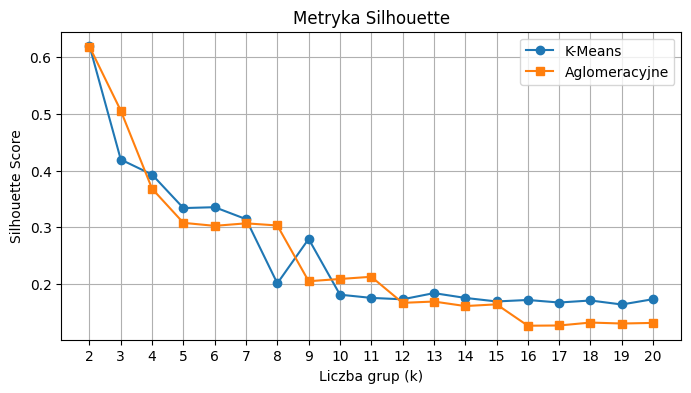

In [ ]:
sil_kmeans = []
sil_agg = []
k_range = range(2, 21)

for k in k_range:
    km_lbls = KMeans(n_clusters=k, n_init=20, random_state=2).fit_predict(ekspresja)
    agg_lbls = AgglomerativeClustering(n_clusters=k).fit_predict(ekspresja)

    sil_kmeans.append(silhouette_score(ekspresja, km_lbls))
    sil_agg.append(silhouette_score(ekspresja, agg_lbls))

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_kmeans, label='K-Means', marker='o')
plt.plot(k_range, sil_agg, label='Aglomeracyjne', marker='s')
plt.title('Metryka Silhouette')
plt.xlabel('Liczba grup (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

**Kluczowe wnioski z oceny jakości klastrowania (Metryka Silhouette):**

1. Wykres udowadnia, że czysto matematycznie najlepszy możliwy podział tego zbioru to zaledwie $k=2$ (wskaźnik powyżej 0.6). Idealnie pokrywa się to z dwoma głównymi pniami z dendrogramu. Zwiększanie liczby grup drastycznie obniża wynik. Przy $k=16$ wskaźnik wynosi poniżej 0.20, co oznacza, że w wielowymiarowej przestrzeni klastry mają rozmyte granice i częściowo na siebie zachodzą.

2. Werdykt dla docelowego $k=16$ (K-Means wygrywa): Porównując obie metody w interesującym nas punkcie ($k=16$), wyraźnym zwycięzcą okazuje się algorytm K-Means (niebieska linia). W wyższych zakresach liczby grup K-Means lepiej radzi sobie z utrzymaniem zwartości klastrów, podczas gdy dla metody hierarchicznej (pomarańczowa linia) wskaźnik ten gwałtownie spada.

Zad. 16: Nowy profil x trafił do grupy nr: 9


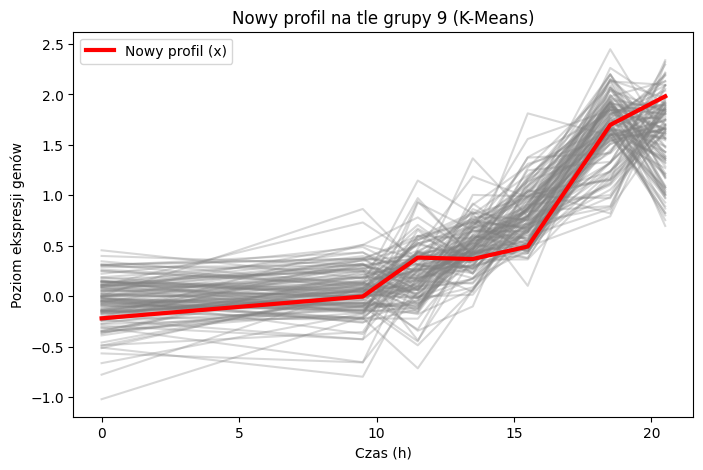

Geny przypisane do tej grupy:
YAL061W, YAR027W, YBR026C, YBR287W, YDL004W, YDL124W, YDR358W, YGR019W, YGR111W, YJL164C, YJL166W, YJR104C, YKL065C, YKL067W, YKL091C, YLR168C, YLR290C, YMR155W, YMR173W, YMR181C, YNL037C, YOR244W, YPL186C, YPL230W, NORF 7, YAL060W, YBR214W, YBR256C, YCR039C, YCR061W, YDL181W, YDR125C, YER044C, YGR044C, YGR130C, YGR132C, YGR182C, YIL169C, YJR034W, YKL036C, YLR093C, YLR271W, YNL252C, YOL117W, YOL048C, YOL053W, YOL071W, YPL165C, YPR026W, YPR098C, NORF 8, YBL075C, YBL107C, YBR056W, YBR126C, YBR269C, YCL042W, YGL006W, YGL192W, YGL198W, YGR149W, YJL102W, YJR019C, YKL150W, YLR252W, YLR038C, YKR067W, YML091C, YMR133W, YMR278W, YNL045W, YNL115C, YOL082W, YOR136W, YPL004C, YPL078C, YPL196W, YAL017W, YBL038W, YBR039W, YBR149W, YBR230C, YCR097W, YDL067C, YDR059C, YDR085C, YDR231C, YDR329C, YDR377W, YER035W, YER061C, YGL047W, YGL121C, YGL199C, YGR028W, YGR194C, YHL024W, YHR016C, YHR209W, YIL087C, YJL151C, YJL155C, YJR048W, YLR251W, YLR257W, YLR259C, YLR081W, YLR395C, 

In [ ]:
import math
from IPython.display import display

x_new = np.array([[-0.2205, -0.0041, 0.3821, 0.3680, 0.4918, 1.6983, 1.9820]])
pred_label = kmeans.predict(x_new)[0]
print(f"Zad. 16: Nowy profil x trafił do grupy nr: {pred_label}")

plt.figure(figsize=(8, 5))
cluster_data = ekspresja[kmeans_labels == pred_label]
for profile in cluster_data:
    plt.plot(czas, profile, color='gray', alpha=0.3)
plt.plot(czas, x_new[0], color='red', linewidth=3, label='Nowy profil (x)')
plt.title(f'Nowy profil na tle grupy {pred_label} (K-Means)')
plt.xlabel('Czas (h)')
plt.ylabel('Poziom ekspresji genów')
plt.legend()
plt.show()

# Wypisanie genów w tej grupie
geny_w_grupie = np.array(geny)[kmeans_labels == pred_label]
print("Geny przypisane do tej grupy:")
print(", ".join(geny_w_grupie))

**Kluczowe wnioski z klasyfikacji nowego profilu (Predykcja K-Means):**

1. **Zdolność predykcyjna wyuczonego modelu:** Ten wykres udowadnia, że algorytm K-Means z powodzeniem przeszedł od fazy uczenia do fazy predykcji. Model wykorzystał wyliczony wcześniej układ przestrzenny (pozycję centroidu grupy 9), aby błyskawicznie i poprawnie sklasyfikować zupełnie nowe, nieznane mu wcześniej dane (profil $x$).

2. **Bezbłędna walidacja wizualna:** Czerwona linia (nowy profil) idealnie wpasowuje się w korytarz wyznaczony przez szare linie genów z grupy 9. Zachowuje ten sam specyficzny, biologiczny rytm: płaski, stabilny poziom ekspresji do około 10. godziny, a następnie gwałtowny wzrost. Oznacza to, że matematyczne przypisanie na podstawie najmniejszej odległości Euklidesowej ma 100% sensu logicznego i wizualnego.

#D. Wnioski końcowe

1. Przebieg ekspresji genów charakteryzuje się wysoką wymiarowością i złożoną dynamiką czasową. Tę właściwość należy uwzględnić na etapie wstępnego przetwarzania danych. Zastosowanie analizy głównych składowych (PCA) pozwoliło na efektywną redukcję wymiarowości – zrzutowanie 7-wymiarowych profili na przestrzeń 2D i 3D przy zachowaniu blisko 80% pierwotnej wariancji. Umożliwiło to poprawną, wizualną identyfikację ukrytych struktur (skupisk) w zbiorze.

2. Algorytm K-średnich jest silnie uzależniony od warunków początkowych (stanu stochastycznego). Optymalizacja modelu wymagała zastosowania wielokrotnej inicjalizacji początkowych centroidów (parametr n_init). Analiza wykazała, że dla pojedynczego uruchomienia algorytm często zatrzymuje się w minimach lokalnych. Parametr ten ma kluczowe znaczenie dla stabilności i jakości ostatecznej predykcji.

3. Dokładność i struktura podziału zależą od wybranej metody klasteryzacji. Zauważono naturalną asymetrię w liczebności grup. Metoda K-średnich wykazała tendencję do tworzenia pojedynczych, dominujących klastrów. Z kolei algorytm aglomeracyjny (hierarchiczny) z zastosowaniem kryterium Warda skuteczniej separował dane odstające (szum biologiczny), zamykając je w nielicznych, izolowanych gałęziach dendrogramu.

4. Wybór liczby klastrów ($k$) stanowi kompromis pomiędzy optimum matematycznym a celem dziedzinowym. Analiza metryki Silhouette oraz Metoda Łokcia wskazały, że najwyższą spójność matematyczną zbiór wykazuje dla podziału na 2 do 4 super-grup. Zwiększenie tej liczby do docelowego $k=16$ skutkuje spadkiem wskaźnika sylwetkowego (wzrost rozmycia granic klastrów), jednak jest niezbędne do wyizolowania specyficznych, mniejszych ścieżek biologicznych. Dla $k=16$ algorytm K-Means osiągnął nieznacznie wyższą zwartość grup niż metoda hierarchiczna.

5. Skonstruowany model wykazuje wysoką zdolność predykcyjną. Weryfikacja działania algorytmu w trybie klasyfikacji na nowych danych (nowy profil ekspresji) potwierdziła poprawność wyznaczonych centroidów. Wyznaczona minimalna odległość Euklidesowa bezbłędnie i w krótkim czasie przyporządkowała nowy wektor do grupy o identycznej dynamice czasowej. Sugeruje to wysoką przydatność modelu do automatyzacji przyszłych analiz mikromacierzowych.

#Literatura

1. Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani, *An Introduction to Statistical Learning: with Applications in Python, Springer*, New York 2021, rozdz. 12: „Unsupervised Learning”.
2. Bishop, C. M. *Pattern Recognition and Machine Learning. Springer.*, 2006 (Rozdział 9: Mixture Models and EM).